# 🏠 Real Estate Intelligence Platform
## Notebook 05 — Explainable AI (SHAP)

**Project:** AI-Powered Real Estate Intelligence, Valuation & Investment Recommendation Platform  
**Phase:** Phase 7 (Explainable AI)  
**Model:** XGBoost (best model, R²=0.9769)  
**Input:** data/model_df.csv  

---

### Objectives
- Global Explainability — which features matter most overall
- Local Explainability — why was a specific property priced this way
- Feature Importance — ranked feature contributions

### SHAP Outputs
| # | Plot | Type |
|---|---|---|
| 1 | SHAP Summary Plot | Global |
| 2 | SHAP Bar Plot | Global — mean absolute importance |
| 3 | SHAP Waterfall Plot | Local — single property explanation |
| 4 | SHAP Force Plot | Local — visual push/pull explanation |

In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import json
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load model and data
model = joblib.load('../models/best_model.pkl')

with open('../models/feature_columns.json', 'r') as f:
    FEATURES = json.load(f)

TARGET = 'Estimated_Price'

df = pd.read_csv('../data/processed/model_df.csv')
X = df[FEATURES]
y = df[TARGET]

# Use sample for SHAP (full 250k is slow)
X_sample = X.sample(2000, random_state=42)

print("Model loaded:", type(model).__name__)
print("Features:", len(FEATURES))
print("SHAP sample size:", X_sample.shape)

Model loaded: XGBRegressor
Features: 34
SHAP sample size: (2000, 34)


In [2]:
# TreeExplainer is optimized for XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print("SHAP values shape:", shap_values.shape)
print("Expected value (base):", explainer.expected_value.round(2))

SHAP values shape: (2000, 34)
Expected value (base): 313.49


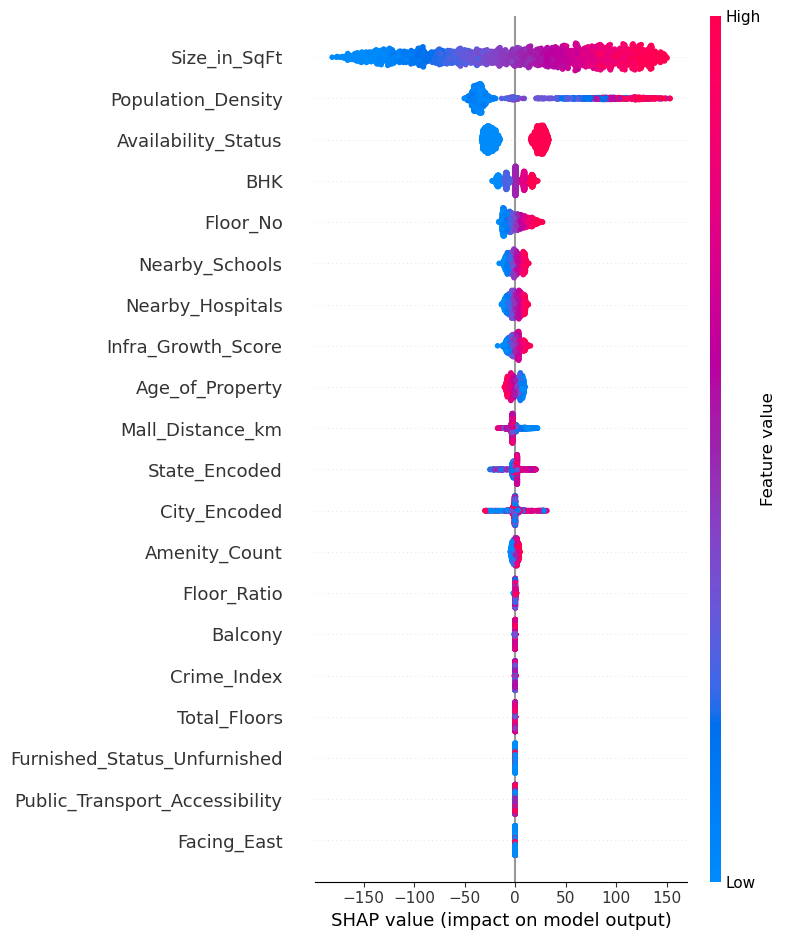

In [3]:
#  Global: SHAP Summary Plot:
shap.summary_plot(shap_values, X_sample, 
                   feature_names=FEATURES,
                   show=True)

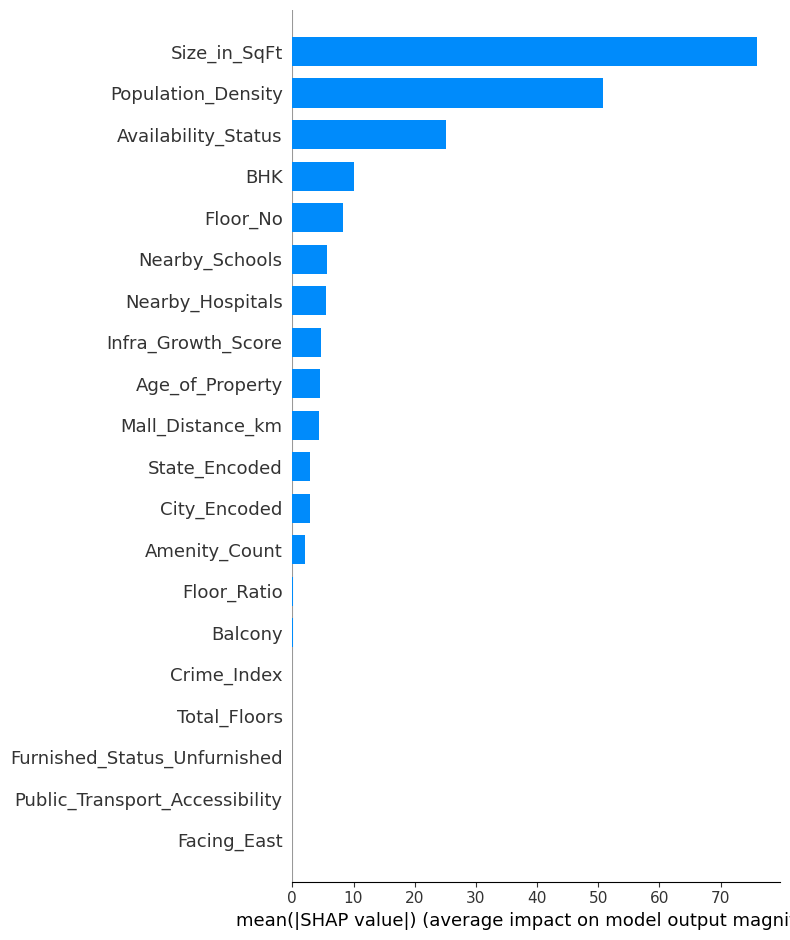

In [4]:
# Global: SHAP Bar Plot (mean absolute importance):
shap.summary_plot(shap_values, X_sample,
                   feature_names=FEATURES,
                   plot_type='bar',
                   show=True)

In [6]:
# Save SHAP importance for Streamlit dashboard
shap_importance = pd.DataFrame({
    'Feature': FEATURES,
    'SHAP_Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

print("Top 10 most important features:")
print(shap_importance.head(10).to_string(index=False))

shap_importance.to_csv('../models/shap_importance.csv', index=False)
print("\nSaved shap_importance.csv")

Top 10 most important features:
            Feature  SHAP_Importance
       Size_in_SqFt        75.915154
 Population_Density        50.831127
Availability_Status        25.103535
                BHK        10.092272
           Floor_No         8.230227
     Nearby_Schools         5.674871
   Nearby_Hospitals         5.491014
 Infra_Growth_Score         4.615232
    Age_of_Property         4.561047
   Mall_Distance_km         4.330199

Saved shap_importance.csv


Property details:
       Size_in_SqFt  BHK  Population_Density  Availability_Status  Age_of_Property
38683           692    4                3800                    1                3

Actual price: ₹271.53 Lakhs
Base value: ₹313.49 Lakhs
Predicted: ₹256.81 Lakhs


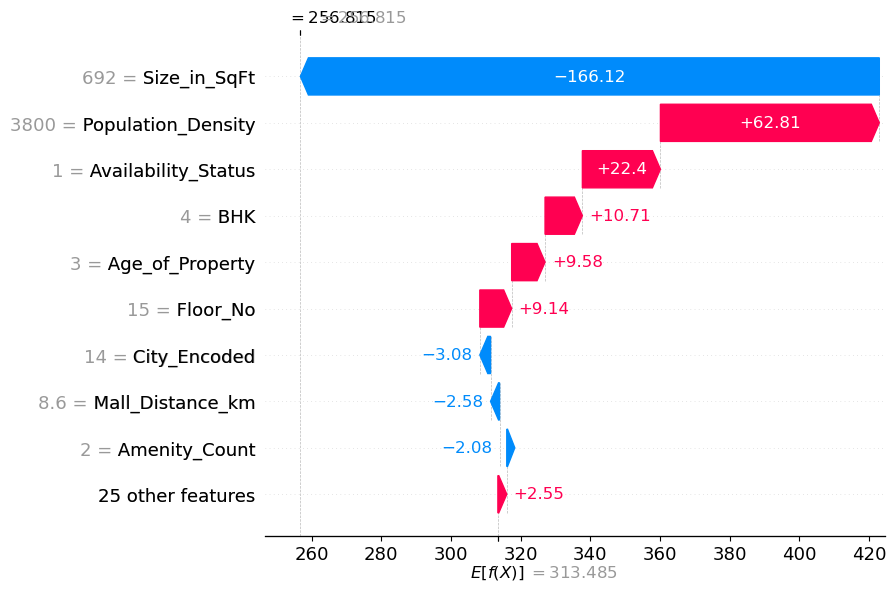

In [7]:
# Local: Waterfall plot (single property):
# Pick one property to explain
sample_idx = 0
sample_property = X_sample.iloc[sample_idx:sample_idx+1]
shap_single = explainer.shap_values(sample_property)

print("Property details:")
print(sample_property[['Size_in_SqFt', 'BHK', 'Population_Density', 
                         'Availability_Status', 'Age_of_Property']].to_string())
print(f"\nActual price: ₹{y.iloc[X_sample.index[sample_idx]]:.2f} Lakhs")
print(f"Base value: ₹{explainer.expected_value:.2f} Lakhs")
print(f"Predicted: ₹{model.predict(sample_property)[0]:.2f} Lakhs")

# Waterfall plot
shap.waterfall_plot(
    shap.Explanation(
        values=shap_single[0],
        base_values=explainer.expected_value,
        data=sample_property.values[0],
        feature_names=FEATURES
    )
)

In [8]:
import pickle

# Save explainer and sample for Streamlit SHAP page
with open('../models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

# Save shap_values and X_sample for global plots in Streamlit
np.save('../models/shap_values.npy', shap_values)
X_sample.to_csv('../models/shap_sample.csv', index=False)

print("Saved shap_explainer.pkl")
print("Saved shap_values.npy")
print("Saved shap_sample.csv")

Saved shap_explainer.pkl
Saved shap_values.npy
Saved shap_sample.csv


---

## ✅ Notebook 05 Complete

### SHAP Global Explainability — Top 10 Features
| Rank | Feature | SHAP Importance | Interpretation |
|---|---|---|---|
| 1 | Size_in_SqFt | 75.92 | Primary price driver — larger = more expensive |
| 2 | Population_Density | 50.83 | City tier effect — denser cities command premium |
| 3 | Availability_Status | 25.10 | Ready-to-move commands higher price than underconstruction |
| 4 | BHK | 10.09 | More bedrooms = higher price, secondary to size |
| 5 | Floor_No | 8.23 | Higher floors command slight premium |
| 6 | Nearby_Schools | 5.67 | Better school access adds value |
| 7 | Nearby_Hospitals | 5.49 | Healthcare proximity adds value |
| 8 | Infra_Growth_Score | 4.62 | Better infrastructure = higher price |
| 9 | Age_of_Property | 4.56 | Newer properties priced higher |
| 10 | Mall_Distance_km | 4.33 | Closer to mall = higher price |

### SHAP Local Explainability — Sample Property
| Item | Value |
|---|---|
| Size | 692 sqft |
| BHK | 4 |
| Population Density | 3800 (Gurgaon) |
| Availability | Ready to Move |
| Age | 3 years |
| Base Value | ₹313.49 Lakhs |
| Predicted Price | ₹256.81 Lakhs |
| Actual Price | ₹271.53 Lakhs |
| Error | ₹14.72 Lakhs (5.4%) |

### Key Insights
- Size and Population Density together explain majority of price variance
- Availability_Status (Ready vs Underconstruction) is surprisingly strong signal (rank 3)
- Facing, Owner_Type, Security show near-zero SHAP importance — confirm synthetic data artifact
- Local explanation error of only ₹14.72L on ₹271L property = 5.4% — excellent precision

### Saved Artifacts
| File | Description |
|---|---|
| models/shap_explainer.pkl | TreeExplainer for Streamlit inference |
| models/shap_values.npy | Precomputed SHAP values (2000 samples) |
| models/shap_sample.csv | Sample features for global plots |
| models/shap_importance.csv | Ranked feature importance table |

### Next Step
→ Open `06_streamlit_app.py` to build the interactive dashboard